In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gen_catalyst_design.db import Database, load_data_from_db
from ase.io import read

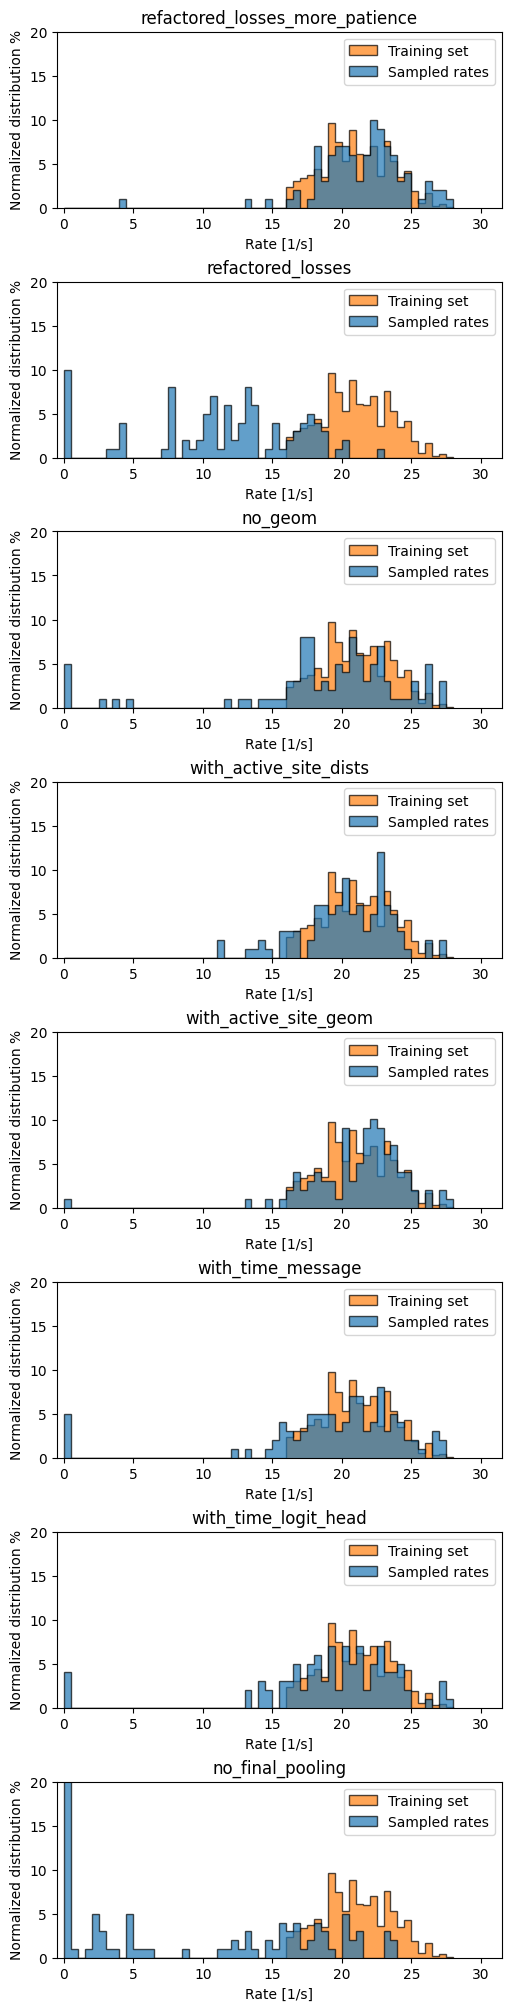

In [9]:
atoms_list = read(filename="../high_rate_structs.traj", index=":")
train_rates = np.array([atoms.info["rate"] for atoms in atoms_list])
element_pool = ["Rh", "Cu", "Pd", "Au"]
miller_index = "100"


temp = 1.0
models = [
    "refactored_losses_more_patience",
    "refactored_losses",
    "no_geom",
    "with_active_site_dists",
    "with_active_site_geom",
    "with_time_message",
    "with_time_logit_head",
    "no_final_pooling"
]

step = 2.5
fig, axs = plt.subplots(len(models), 1, figsize=(5,20), layout="constrained")
for ax, model in zip(axs, models):
    ax.set_title(model)
    database = Database.establish_connection(filename=f"rate_evals_{temp}.db", miller_index=miller_index, pth_header=model)
    datadicts = load_data_from_db(database=database)
    sampled_rates = np.array([datadict["rate"] for datadict in datadicts])
    rate_interval = 0.5
    rate_max = np.max([np.max(sampled_rates), np.max(train_rates)])
    rate_min = 0.0

    i = 0
    hist_prior = None
    y_lims = 0.2*100
    labels = [
        "Training set",
        "Sampled rates"
    ]
    classes = np.arange(1.0, np.ceil(rate_max)+step, step)#np.linspace(1.0, np.ceil(rate_max), 5)
    for rates, color, label in zip([train_rates, sampled_rates], ["C1", "C0"], labels):
        bins = np.arange(rate_min, rate_max, rate_interval)
        hist, edges = np.histogram(rates, bins=bins)
        hist_norm = hist/np.sum(hist)
        ax.stairs(hist_norm*100, edges=edges, fill=True, alpha=0.7, edgecolor="k", linewidth=1, color=color, label=label)
        ax.set_xlim([-0.5, np.ceil(rate_max)+step])
        ax.set_ylim([0.0, y_lims])
        ax.set_ylabel("Normalized distribution %")
        ax.set_xlabel("Rate [1/s]")
    ax.legend()
plt.savefig(f"temp_{temp}.png")

/var/folders/rw/nf9b9qh56ys12sgyk49vlcsw0000gn/T/ipykernel_43352/1239844928.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


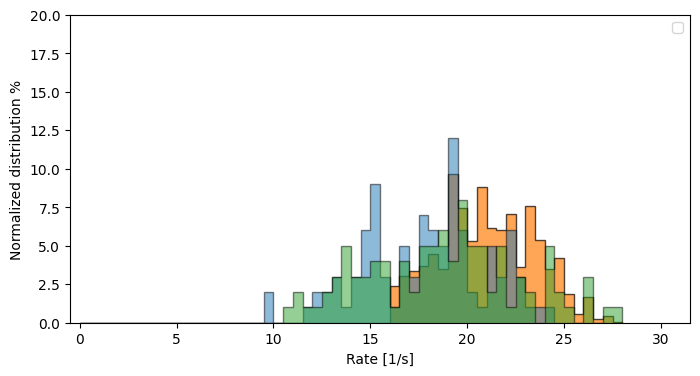

In [75]:
atoms_list = read(filename="../high_rate_structs.traj", index=":")
train_rates = np.array([atoms.info["rate"] for atoms in atoms_list])
element_pool = ["Rh", "Cu", "Pd", "Au"]
miller_index = "100"
fig, ax = plt.subplots(figsize=(8,4))
train_rates#rates = np.array([datadict["rate"] for datadict in datadicts])
rate_interval = 0.5
rate_max = np.max(train_rates)
rate_min = 0.0

i = 0
hist_prior = None
y_lims = 0.2*100
labels = [
    "Training set",
    "Sampled rates"
]

step = 2.5
classes = np.arange(1.0, np.ceil(rate_max)+step, step)#np.linspace(1.0, np.ceil(rate_max), 5)
ax.set_xlim([-0.5, np.ceil(rate_max)+step])
ax.set_ylim([0.0, y_lims])
ax.set_ylabel("Normalized distribution %")
ax.set_xlabel("Rate [1/s]")


bins = np.arange(rate_min, rate_max, rate_interval)
hist, edges = np.histogram(train_rates, bins=bins)
hist_norm = hist/np.sum(hist)
ax.stairs(hist_norm*100, edges=edges, fill=True, alpha=0.7, edgecolor="k", linewidth=1, color="C1")

for model, color in zip(["model_005", "model_006"], ["C0", "C2"]):
    database = Database.establish_connection(filename="rate_evals_1.db", miller_index=miller_index, pth_header=model)
    datadicts = load_data_from_db(database=database)
    sampled_rates = np.array([datadict["rate"] for datadict in datadicts])
    hist, edges = np.histogram(sampled_rates, bins=bins)
    hist_norm = hist/np.sum(hist)
    ax.stairs(hist_norm*100, edges=edges, fill=True, alpha=0.5, edgecolor="k", linewidth=1, color=color)

ax.legend()

In [61]:
def get_avg_elem_stats(element_lists, element_pool):
    tot_atom_count = 0
    element_count = {}
    for element in element_pool:
        for element_list in element_lists:
            count = element_list.count(element)
            if element in element_count:
                element_count[element]+=count
            else:
                element_count[element]=count
            tot_atom_count+=count
    for element in element_count:
        element_count[element]/=tot_atom_count
    return element_count

In [62]:
train_element_lists = [atoms.get_chemical_symbols() for atoms in atoms_list]
train_stats = get_avg_elem_stats(element_lists=train_element_lists, element_pool=element_pool)

sample_element_lists = [datadict["elements"] for datadict in datadicts]
sample_stats = get_avg_elem_stats(element_lists=sample_element_lists, element_pool=element_pool)
print(train_stats)
print(np.array([train_stats[elem] for elem in train_stats]).sum())
print(sample_stats)
print(np.array([sample_stats[elem] for elem in sample_stats]).sum())

{'Rh': 0.17482615966904322, 'Cu': 0.4112490097702667, 'Pd': 0.41316785494234665, 'Au': 0.0007569756183434557}
1.0
{'Rh': 0.1717171717171717, 'Cu': 0.4001924001924002, 'Pd': 0.42664742664742666, 'Au': 0.001443001443001443}
1.0


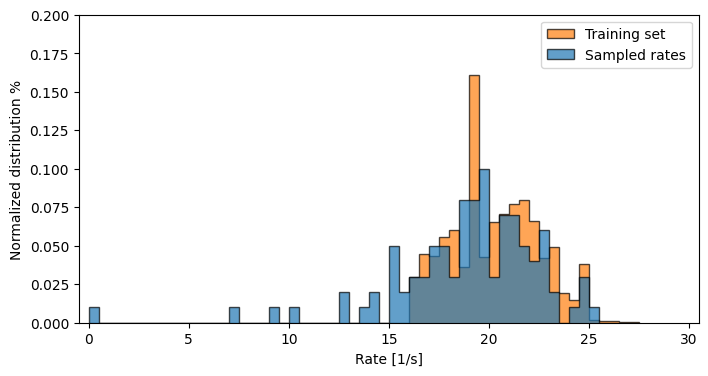

In [12]:
atoms_list = read(filename="../filtered_samples.traj", index=":")
train_rates = np.array([atoms.info["rate"] for atoms in atoms_list])

model = "site_emb_filtered"
miller_index = "100"
database = Database.establish_connection(filename="rate_evals.db", miller_index=miller_index, pth_header=model)
datadicts = load_data_from_db(database=database)
sampled_rates = np.array([datadict["rate"] for datadict in datadicts])

fig, ax = plt.subplots(figsize=(8,4))
train_rates#rates = np.array([datadict["rate"] for datadict in datadicts])
rate_interval = 0.5
rate_max = np.max(train_rates)
rate_min = 0.0

i = 0
hist_prior = None
y_lims = 0.2
labels = [
    "Training set",
    "Sampled rates"
]

step = 2.5
classes = np.arange(1.0, np.ceil(rate_max)+step, step)#np.linspace(1.0, np.ceil(rate_max), 5)
for rates, color, label in zip([train_rates, sampled_rates], ["C1", "C0"], labels):
    bins = np.arange(rate_min, rate_max, rate_interval)
    hist, edges = np.histogram(rates, bins=bins)
    hist_norm = hist/np.sum(hist)
    ax.stairs(hist_norm, edges=edges, fill=True, alpha=0.7, edgecolor="k", linewidth=1, color=color, label=label)
    ax.set_xlim([-0.5, np.ceil(rate_max)+step])
    ax.set_ylim([0.0, y_lims])
    ax.set_ylabel("Normalized distribution %")
    ax.set_xlabel("Rate [1/s]")
ax.legend()

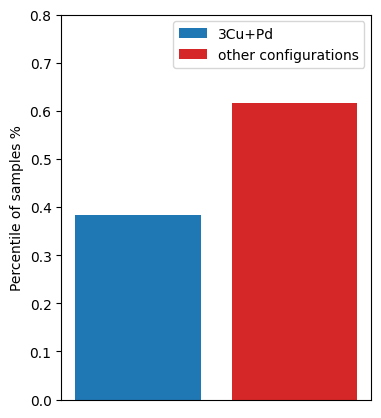

In [15]:
fig, ax = plt.subplots(figsize=(4,5))
model = "active_site_emb_only_filtered"
miller_index = "100"
database = Database.establish_connection(filename="rate_evals.db", miller_index=miller_index, pth_header=model)
datadicts = load_data_from_db(database=database)
num_samples = len(datadicts)
sampled_rates = np.array([datadict["rate"] for datadict in datadicts])
site_indices = [0,1,2,3]

element_counts = 0
for datadict in datadicts:
    elements = datadict["elements"]
    filtered_elements = [elements[site_index] for site_index in site_indices]
    cu_count, pd_count = filtered_elements.count("Cu"), filtered_elements.count("Pd")
    if cu_count == 3 and pd_count == 1:
        element_counts+=1
ax.set_ylabel("Percentile of samples %")
ax.set_ylim([0.0, 0.8])
ax.bar(x=0, height=element_counts/num_samples, color="C0", label="3Cu+Pd")
ax.bar(x=1, height=(num_samples-element_counts)/num_samples, color="C3", label="other configurations")
ax.set_xticks([])
ax.legend()
